In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Dataset.csv')

In [4]:
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [5]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [6]:
numerical = df.select_dtypes(include=['int64','float64']).columns
categorical = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical.tolist())
print("Categorical Columns:", categorical.tolist())


Numerical Columns: ['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
Categorical Columns: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason', 'Payment Method']


In [7]:
# Fill or drop missing values (based on column importance)
df['Driver Ratings'].fillna(df['Driver Ratings'].mean(), inplace=True)
df['Customer Rating'].fillna(df['Customer Rating'].mean(), inplace=True)
df['Booking Value'].fillna(df['Booking Value'].median(), inplace=True)

C:\Users\shrij\AppData\Local\Temp\ipykernel_19988\3565114453.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Driver Ratings'].fillna(df['Driver Ratings'].mean(), inplace=True)
C:\Users\shrij\AppData\Local\Temp\ipykernel_19988\3565114453.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [8]:
# Convert Date and Time to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time

C:\Users\shrij\AppData\Local\Temp\ipykernel_19988\1201249321.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time


In [9]:
# Most and least popular vehicle types
print("\n Vehicle Type Popularity:")
print(df['Vehicle Type'].value_counts())


 Vehicle Type Popularity:
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64


In [10]:
# Average ride distance and booking value
print("\n Average Ride Distance and Booking Value:")
print(df[['Ride Distance', 'Booking Value']].mean())


 Average Ride Distance and Booking Value:
Ride Distance     24.637012
Booking Value    478.121220
dtype: float64


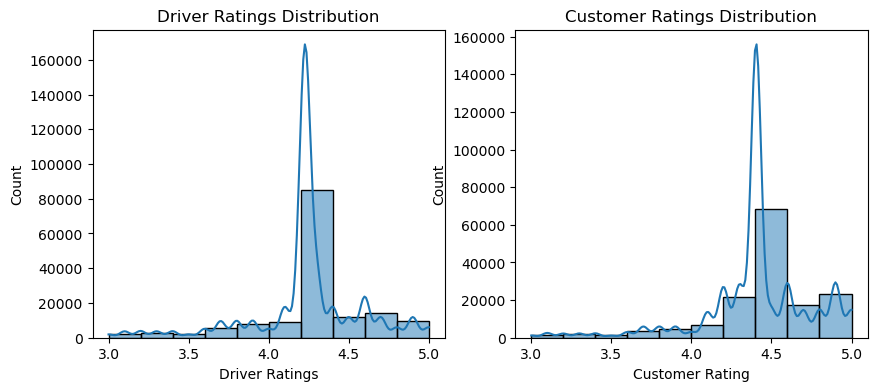

In [11]:
# Distribution of driver and customer ratings
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Driver Ratings'], bins=10, kde=True)
plt.title('Driver Ratings Distribution')
plt.subplot(1,2,2)
sns.histplot(df['Customer Rating'], bins=10, kde=True)
plt.title('Customer Ratings Distribution')
plt.show()

In [12]:
# Most common cancellation reasons
print("\n Reasons for Customer Cancellation:")
if 'Reason for Cancelling by Customer' in df.columns:
    print(df['Reason for Cancelling by Customer'].value_counts().head())
else:
    print("Column not found!")

print("\n Reasons for Driver Cancellation:")
if 'Driver Cancellation Reason' in df.columns:
    print(df['Driver Cancellation Reason'].value_counts().head())
else:
    print("Column not found!")


 Reasons for Customer Cancellation:
Column not found!

 Reasons for Driver Cancellation:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64


In [13]:
# Frequent cancellers
if 'Customer ID' in df.columns and 'Cancelled Rides by Customer' in df.columns:
    top_cancellers = df.groupby('Customer ID')['Cancelled Rides by Customer'].sum().sort_values(ascending=False).head(10)
    print("\nTop 10 Frequent Cancellers:")
    print(top_cancellers)


Top 10 Frequent Cancellers:
Customer ID
"CID5251785"    2.0
"CID2358909"    2.0
"CID5488244"    2.0
"CID5505307"    2.0
"CID7939117"    2.0
"CID8416905"    2.0
"CID8519067"    2.0
"CID8887672"    2.0
"CID2124790"    1.0
"CID1600735"    1.0
Name: Cancelled Rides by Customer, dtype: float64


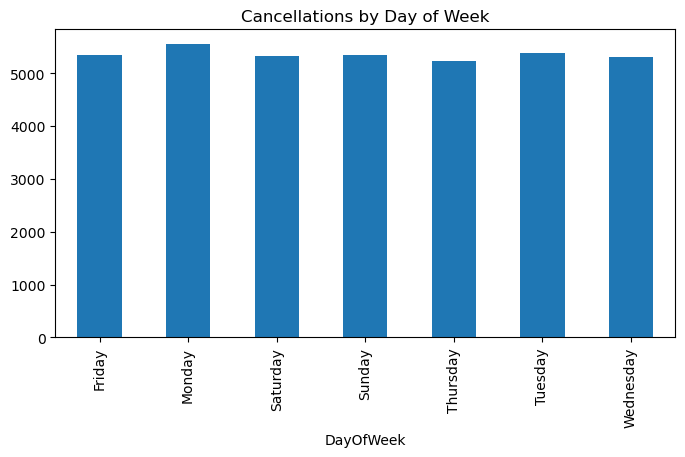

In [14]:
# Cancellation pattern by day of week
if 'Date' in df.columns and 'Booking Status' in df.columns:
    df['DayOfWeek'] = df['Date'].dt.day_name()
    cancel_by_day = df[df['Booking Status'].str.contains('Cancel', case=False, na=False)].groupby('DayOfWeek').size()
    cancel_by_day.plot(kind='bar', title='Cancellations by Day of Week', figsize=(8,4))
    plt.show()

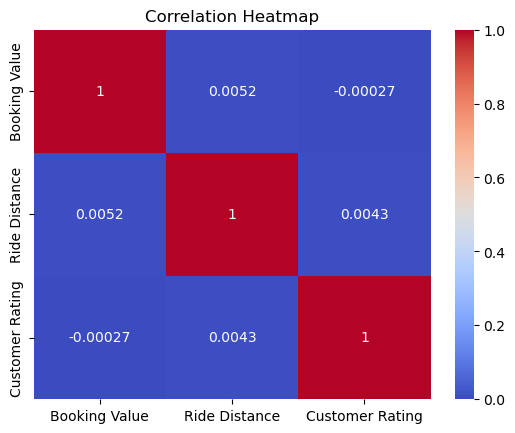

In [15]:
# # Correlation between value, distance, and satisfaction
corr = df[['Booking Value', 'Ride Distance', 'Customer Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
if 'Driver Ratings' in df.columns:
    print("\nTop 5 Drivers (Highest Rated):")
    print(df.groupby('Driver Ratings').size().sort_index(ascending=False).head())


Top 5 Drivers (Highest Rated):
Driver Ratings
5.0    2365
4.9    4705
4.8    2328
4.7    4678
4.6    9368
dtype: int64


In [17]:
if 'Driver Ratings' in df.columns:
    print("\nTop 5 Drivers (lowest Rated):")
    print(df.groupby('Driver Ratings').size().sort_index(ascending=False).head())


Top 5 Drivers (lowest Rated):
Driver Ratings
5.0    2365
4.9    4705
4.8    2328
4.7    4678
4.6    9368
dtype: int64


In [18]:
# Average VTAT and CTAT
if 'Avg VTAT' in df.columns and 'Avg CTAT' in df.columns:
    print("\nAverage VTAT:", df['Avg VTAT'].mean())
    print("Average CTAT:", df['Avg CTAT'].mean())



Average VTAT: 8.456351971326164
Average CTAT: 29.149636274509803


In [19]:
# Peak demand locations
if 'Pickup Location' in df.columns:
    print("\n Top 5 Pickup Locations:")
    print(df['Pickup Location'].value_counts().head())


 Top 5 Pickup Locations:
Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64


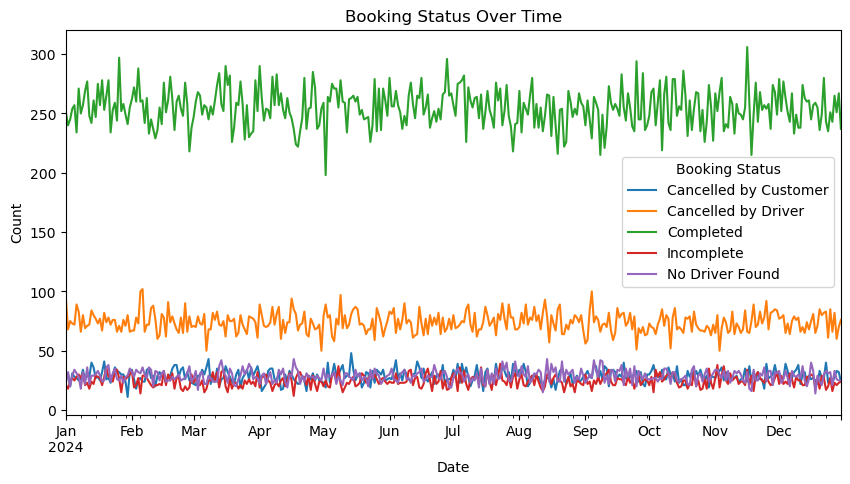

In [20]:
# Booking status trend
if 'Booking Status' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    status_trend = df.groupby(['Date', 'Booking Status']).size().unstack().fillna(0)
    status_trend.plot(figsize=(10,5), title='Booking Status Over Time')
    plt.ylabel('Count')
    plt.show()

In [21]:
print("\n Analysis Completed Successfully!")


 Analysis Completed Successfully!
